# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv("Customers.csv")
df.head()

,index,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency
0,0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0,77183.600000,1.000000
1,1,12347.0,7,2458,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,365,615.714286,0.019126
2,2,12348.0,4,2341,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,282,449.310000,0.014134
3,3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1757.550000,1.000000
4,4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000,1.000000


# Data Preprocessing

## Convert Date Columns

In [5]:
df['LastPurchase'] = pd.to_datetime(df['LastPurchase'])
df['FirstPurchase'] = pd.to_datetime(df['FirstPurchase'])

## Check missing values

In [7]:
print(df.isnull().sum())
df = df.dropna()

index                0
CustomerID           0
TotalTransactions    0
TotalQuantity        0
TotalSpending        0
FirstPurchase        0
LastPurchase         0
CustomerLifetime     0
AvgOrderValue        0
PurchaseFrequency    0
dtype: int64


In [9]:
df['LastPurchase'] = pd.to_datetime(df['LastPurchase'])

# RFM Feature Engineering

## Recency

In [11]:
import datetime as dt

snapshot_date = df['LastPurchase'].max() + dt.timedelta(days=1)

df['Recency'] = (snapshot_date - df['LastPurchase']).dt.days

## Frequency & Monetary

In [13]:
df['Frequency'] = df['TotalTransactions']
df['Monetary'] = df['TotalSpending']

In [15]:
import numpy as np

df['Recency'] = np.log1p(df['Recency'])
df['Frequency'] = np.log1p(df['Frequency'])
df['Monetary'] = np.log1p(df['Monetary'])
df['AvgOrderValue'] = np.log1p(df['AvgOrderValue'])

In [17]:
df = df.dropna()

# Feature Selection

In [19]:
features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AvgOrderValue',
    'PurchaseFrequency',
    'TotalQuantity',
    'CustomerLifetime'
]

X = df[features]

# Feature Scaling

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Feature Importance

In [25]:
cluster_summary = df.groupby('Cluster')[[
    'Recency','Frequency','Monetary','AvgOrderValue',
    'PurchaseFrequency',
    'TotalQuantity',
    'CustomerLifetime'
]].mean()

cluster_summary

,Recency,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,TotalQuantity,CustomerLifetime
Cluster,,,,,,,
0,4.711375,0.772014,4.938216,4.809371,0.923052,100.724428,8.255114
1,4.585457,0.726242,6.173266,6.120229,1.063163,362.287736,0.158019
2,2.373641,2.394848,8.328108,6.049136,0.042704,4395.756426,306.523868
3,3.732268,1.424076,6.764660,5.638286,0.032972,643.624864,167.460369


# Create Labels in Code

In [27]:
cluster_labels = {
    0: "Regular",
    1: "VIP",
    2: "At Risk",
    3: "Low Value"
}

df['Customer_Segment'] = df['Cluster'].map(cluster_labels)

🔷 Cluster 1 → ⭐ VIP Customers
Lowest Recency (2.16) ✅ (recent buyers)
Highest Frequency (2.47) ✅
Highest Monetary (8.35) ✅

👉 These are your BEST customers 
1 → "VIP"

🔷 Cluster 2 → ⚠️ At-Risk Customers
High Recency (4.01) ❌ (haven’t purchased recently)
Medium Frequency
High Monetary (7.25) ✅

👉 These customers: Used to spend well But are becoming inactive
2 → "At Risk"

🔷 Cluster 0 → 🛒 Regular Customers
Moderate Recency (2.70)
Low Frequency (1.09)
Medium Monetary (6.09)

👉 These are: Active but not very loyal Average spenders
0 → "Regular"

🔷 Cluster 3 → 💰 Low-Value Customers
Highest Recency (5.02) ❌ (inactive)
Lowest Frequency (0.81) ❌
Lowest Monetary (5.59) ❌

👉 These are: Inactive Low spenders
3 → "Low Value"

# Evaluation Metrics

In [118]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil = silhouette_score(X_scaled, df['Cluster'])
db = davies_bouldin_score(X_scaled, df['Cluster'])
ch = calinski_harabasz_score(X_scaled, df['Cluster'])

print(f"Silhouette Score: {sil:.2f} % for Cluster = 4")
print(f"Davies-Bouldin Index:{db:.2f}")
print(f"Calinski-Harabasz Score:{ch:.2f}")

Silhouette Score: 0.28 % for Cluster = 4
Davies-Bouldin Index:1.20
Calinski-Harabasz Score:1621.62


# Stability Check

In [42]:
kmeans1 = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
kmeans2 = KMeans(n_clusters=4, random_state=0).fit(X_scaled)
cc = (np.abs(kmeans1.cluster_centers_ - kmeans2.cluster_centers_).mean())
print(f"Cluster Centers Difference : {cc:.2f} %")

Cluster Centers Difference : 0.58 %


“I selected K=4 for clustering because it provides meaningful and actionable customer segments such as VIP, Regular, At-risk, and Low-value customers. While K=2 showed better evaluation metrics, it resulted in overly broad segmentation. K=4 offered a better balance between clustering performance and business interpretability, allowing more effective targeting and decision-making.”

👉 The main reason:

“K=4 provides meaningful and actionable customer segments.”

With 4 clusters, you get:

⭐ VIP Customers
🛒 Regular / Loyal Customers
⚠️ At-Risk Customers
💰 Low-Value Customers

👉 This is ideal because:

Each segment can have different marketing strategies
Easy for business teams to understand and use

“Clustering is not just about metrics, but also about business value.”

In [121]:
# Basic Model Info

In [106]:
print("Number of clusters:", kmeans.n_clusters)
NC = df['Cluster'].value_counts()
NOC = pd.DataFrame(NC)
NOC

Number of clusters: 7


,count
Cluster,
3,1842
1,848
0,831
2,817


# PCA Visualization

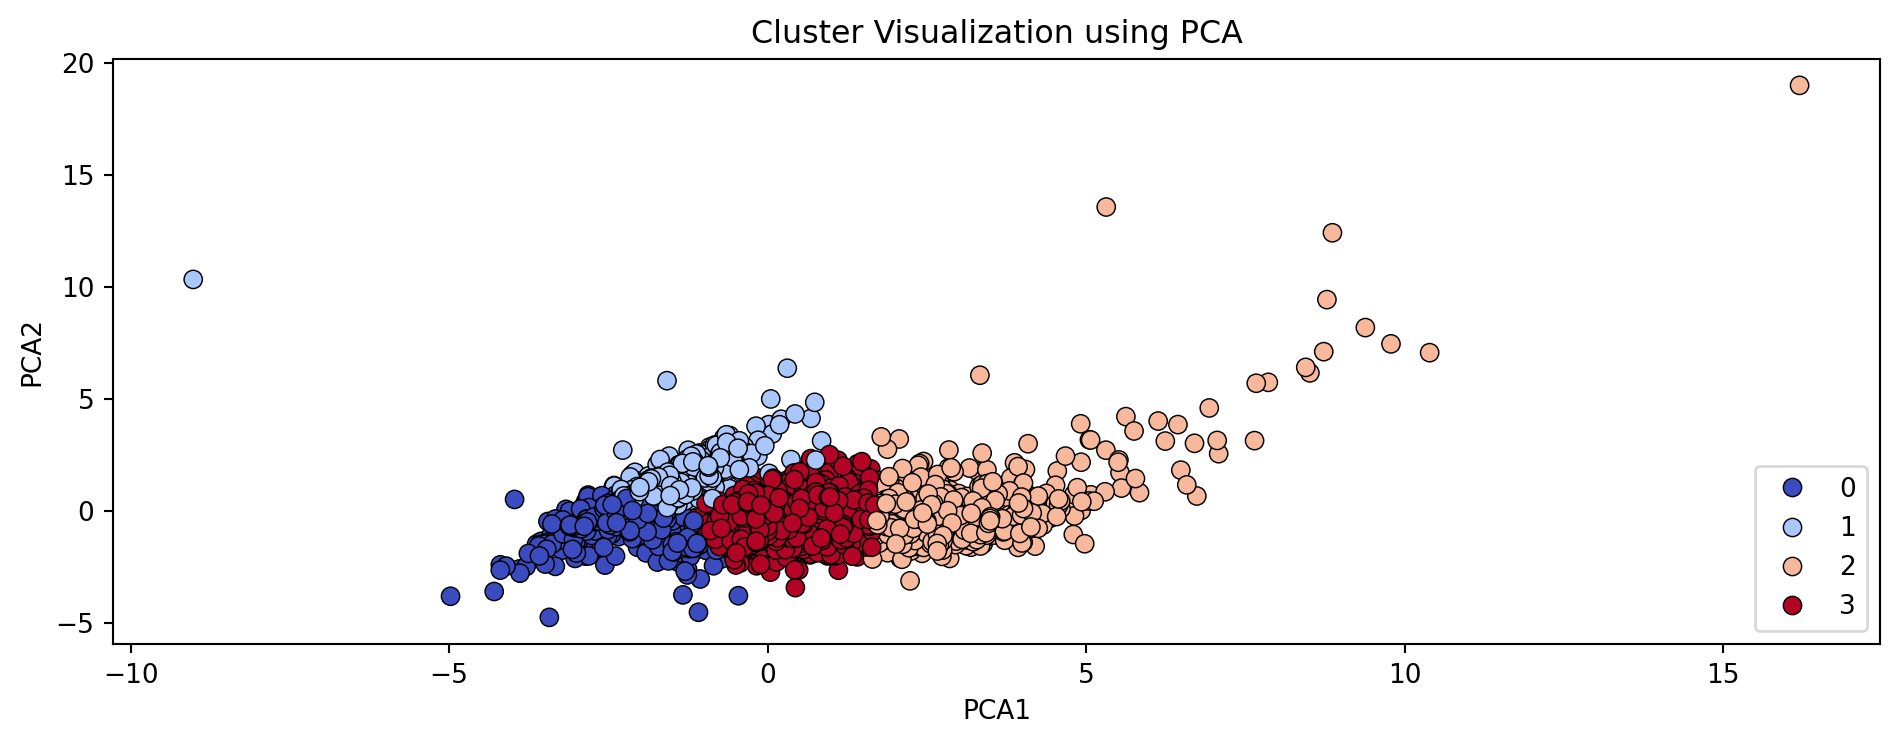

In [132]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(12,4), dpi=190)
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='coolwarm', data=df, ec='k', s=48)
plt.title("Cluster Visualization using PCA")
plt.legend(loc='lower right')
plt.show()

# Segmentation Visualization

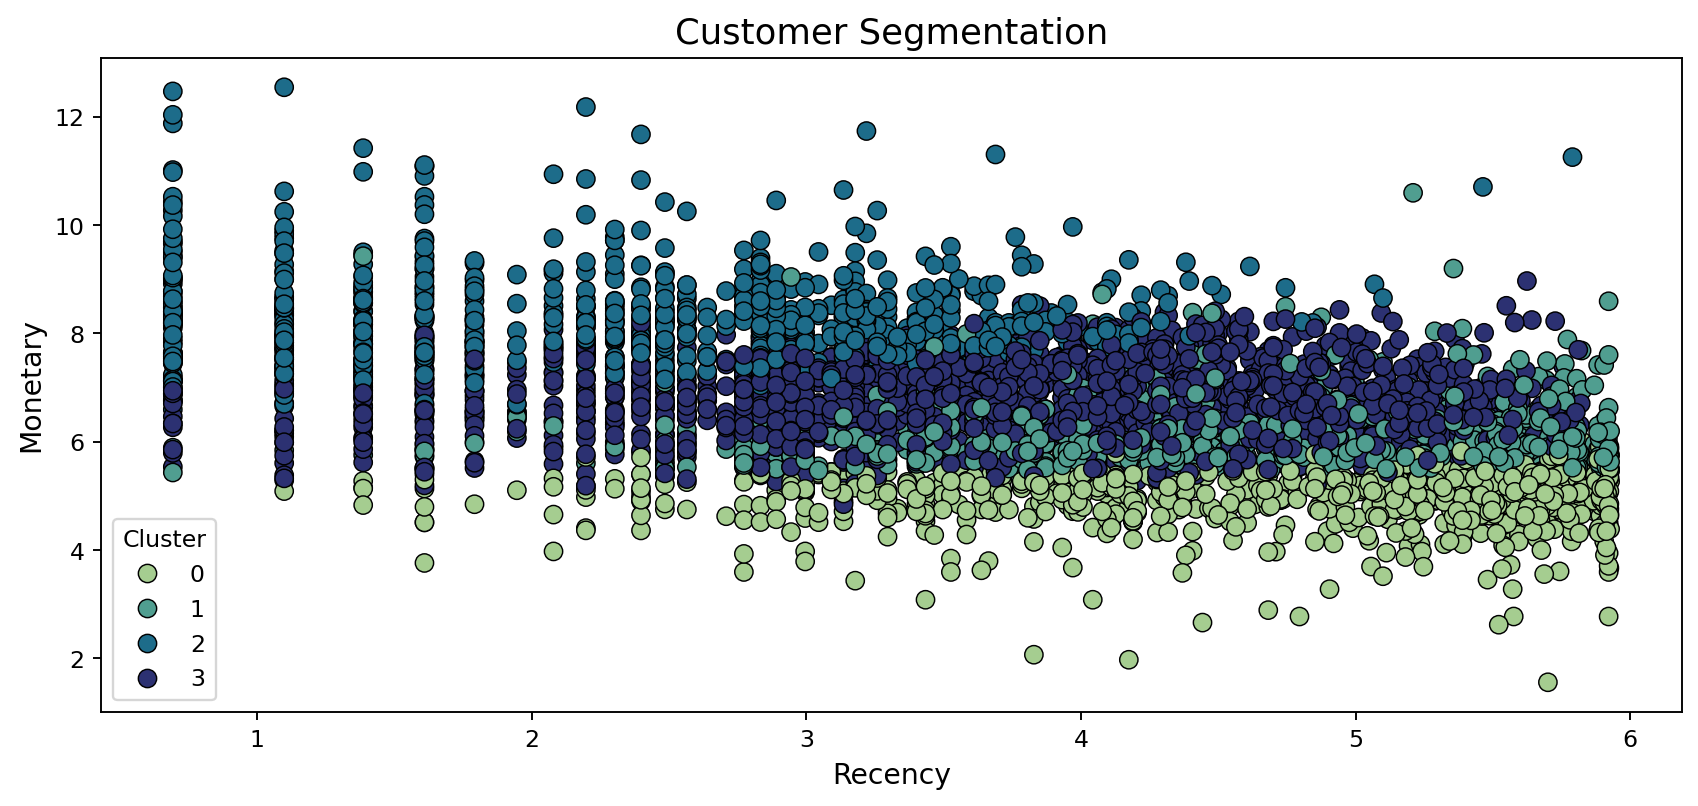

In [89]:
plt.figure(figsize=(12,5), dpi=170)
sns.scatterplot(x=df['Recency'], y=df['Monetary'], hue=df['Cluster'], palette='crest', ec='k', s=60)
plt.title("Customer Segmentation", fontsize=15)
plt.xlabel("Recency", fontsize=12)
plt.ylabel("Monetary", fontsize=12)
plt.show()

# Sample Feature of Data

In [49]:
df.sample(5)[features]

,Recency,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,TotalQuantity,CustomerLifetime
1853,2.639057,2.302585,7.304207,5.112349,0.026012,802,345
2888,4.290459,0.693147,7.631946,7.631946,1.000000,934,0
622,2.995732,1.609438,6.674978,5.292463,0.031746,785,125
2849,4.060443,1.609438,7.167269,5.783287,0.020725,1116,192
706,4.110874,1.098612,4.550292,3.867653,0.015873,90,125


In [85]:
df.iloc[706]

index                                706
CustomerID                       13283.0
TotalTransactions                      2
TotalQuantity                         90
TotalSpending                      93.66
FirstPurchase        2011-06-07 12:39:00
LastPurchase         2011-10-11 09:50:00
CustomerLifetime                     125
AvgOrderValue                   3.867653
PurchaseFrequency               0.015873
Recency                         4.110874
Frequency                       1.098612
Monetary                        4.550292
Cluster                                0
Customer_Segment                 Regular
PCA1                           -1.405655
PCA2                           -2.287699
R_Score                                3
F_Score                                1
M_Score                                1
RFM_Score                            311
Name: 706, dtype: object

In [51]:
df['R_Score'] = pd.qcut(df['Recency'], 4, duplicates='drop').cat.codes + 1
df['F_Score'] = pd.qcut(df['Frequency'], 4, duplicates='drop').cat.codes + 1
df['M_Score'] = pd.qcut(df['Monetary'], 4, duplicates='drop').cat.codes + 1

In [53]:
df['RFM_Score'] = (
    df['R_Score'].astype(str) +
    df['F_Score'].astype(str) +
    df['M_Score'].astype(str)
)

In [55]:
df.head()

,index,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency,...,Frequency,Monetary,Cluster,Customer_Segment,PCA1,PCA2,R_Score,F_Score,M_Score,RFM_Score
0,0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0,11.253955,1.000000,...,0.693147,11.253955,2,At Risk,5.314817,13.561243,4,1,4,414
1,1,12347.0,7,2458,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,365,6.424406,0.019126,...,2.079442,8.368925,2,At Risk,3.215333,-0.159700,1,3,4,134
2,2,12348.0,4,2341,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,282,6.109936,0.014134,...,1.609438,7.494564,3,Low Value,1.340579,0.171708,3,2,4,324
3,3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0,7.472245,1.000000,...,0.693147,7.472245,1,VIP,-0.154383,2.439310,2,1,4,214
4,4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0,5.815324,1.000000,...,0.693147,5.815324,1,VIP,-2.036378,0.997685,4,1,2,412


In [59]:
df.loc[df['Customer_Segment'] == 'VIP'].head(3)

,index,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency,...,Frequency,Monetary,Cluster,Customer_Segment,PCA1,PCA2,R_Score,F_Score,M_Score,RFM_Score
3,3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0,7.472245,1.0,...,0.693147,7.472245,1,VIP,-0.154383,2.439310,2,1,4,214
4,4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0,5.815324,1.0,...,0.693147,5.815324,1,VIP,-2.036378,0.997685,4,1,2,412
7,7,12354.0,1,530,1079.40,2011-04-21 13:11:00,2011-04-21 13:11:00,0,6.985087,1.0,...,0.693147,6.985087,1,VIP,-1.136259,2.293965,4,1,3,413


In [61]:
df.loc[df['Customer_Segment'] == 'Regular'].head(3)

,index,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency,...,Frequency,Monetary,Cluster,Customer_Segment,PCA1,PCA2,R_Score,F_Score,M_Score,RFM_Score
6,6,12353.0,1,20,89.0,2011-05-19 17:47:00,2011-05-19 17:47:00,0,4.49981,1.0,...,0.693147,4.49981,0,Regular,-2.845687,-0.567168,4,1,1,411
14,14,12361.0,1,91,189.9,2011-02-25 13:51:00,2011-02-25 13:51:00,0,5.25175,1.0,...,0.693147,5.25175,0,Regular,-2.411083,0.341711,4,1,1,411
19,19,12367.0,1,173,168.9,2011-12-05 16:48:00,2011-12-05 16:48:00,0,5.13521,1.0,...,0.693147,5.13521,0,Regular,-1.430721,-0.461380,1,1,1,111


In [65]:
df.loc[df['Customer_Segment'] == 'At Risk'].head(3)

,index,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency,...,Frequency,Monetary,Cluster,Customer_Segment,PCA1,PCA2,R_Score,F_Score,M_Score,RFM_Score
0,0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0,11.253955,1.000000,...,0.693147,11.253955,2,At Risk,5.314817,13.561243,4,1,4,414
1,1,12347.0,7,2458,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,365,6.424406,0.019126,...,2.079442,8.368925,2,At Risk,3.215333,-0.159700,1,3,4,134
5,5,12352.0,8,536,2506.04,2011-02-16 12:33:00,2011-11-03 14:37:00,260,5.750205,0.030651,...,2.197225,7.826858,2,At Risk,1.770107,-0.426861,2,3,4,234


In [67]:
df.loc[df['Customer_Segment'] == 'Low Value'].head(3)

,index,CustomerID,TotalTransactions,TotalQuantity,TotalSpending,FirstPurchase,LastPurchase,CustomerLifetime,AvgOrderValue,PurchaseFrequency,...,Frequency,Monetary,Cluster,Customer_Segment,PCA1,PCA2,R_Score,F_Score,M_Score,RFM_Score
2,2,12348.0,4,2341,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,282,6.109936,0.014134,...,1.609438,7.494564,3,Low Value,1.340579,0.171708,3,2,4,324
11,11,12358.0,2,248,1168.06,2011-07-12 10:04:00,2011-12-08 10:26:00,149,6.371663,0.013333,...,1.098612,7.063955,3,Low Value,1.204453,-0.013484,1,1,3,113
13,13,12360.0,3,1165,2662.06,2011-05-23 09:43:00,2011-10-18 15:22:00,148,6.789370,0.020134,...,1.386294,7.887231,3,Low Value,1.131155,1.050881,3,2,4,324


In [155]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [153]:
joblib.dump(kmeans, "customer_segmentation_model.pkl")

['customer_segmentation_model.pkl']